In [ ]:
# %pip install pandas numpy

^C
Note: you may need to restart the kernel to use updated packages.


In [125]:
import pandas as pd
import numpy as np

In [4]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [126]:
print("✅ Ready — pandas:", pd.__version__, "| numpy:", np.__version__)

✅ Ready — pandas: 3.0.0 | numpy: 2.4.1


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --------------------------- ------------ 5.8/8.3 MB 31.4 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 29.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 34.5 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   -------------------------------- ------- 5.8/7.2 MB 27.7 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 25.6 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   -----

In [1]:
import sys, site, os, platform
from pathlib import Path

print("Python executable:", sys.executable)
print("Python version   :", platform.python_version())
print("Platform         :", platform.platform())
print("Site-packages    :", site.getsitepackages() if hasattr(site, "getsitepackages") else site.getusersitepackages())

Python executable: c:\Users\gujin\Dev\J-Notebook\venv\Scripts\python.exe
Python version   : 3.14.2
Platform         : Windows-11-10.0.26100-SP0
Site-packages    : ['c:\\Users\\gujin\\Dev\\J-Notebook\\venv', 'c:\\Users\\gujin\\Dev\\J-Notebook\\venv\\Lib\\site-packages']


# Transforming DataFrames
## Inspecting
basic operations: head(), info(), describe(), shape, columns,

In [145]:
# Read the CSV file into a DataFrame
csv_path = 'data/dummy_employees.csv'
df_csv = pd.read_csv(csv_path)

# Display the DataFrame
display(df_csv)

# Inspecting the DataFrame
print("\nHead:", df_csv.head()) # head(): Display the first few rows of the DataFrame
print("\nShape:", df_csv.shape) # shape: Get the number of rows and columns in the DataFrame
print("\nColumns:", df_csv.columns) # columns: Get the column names of the DataFrame
print("\nInfo:") 
display(df_csv.info()) # info(): Get a concise summary of the DataFrame, including data types and non-null counts
print("\nDescribe:")
display(df_csv.describe()) # describe(): Generate a few summary statistics for each column


,Name,Age,Sex,City,Occupation,Salary
0,Alice,30,Female,New York,Engineer,70000
1,Bob,30,Male,London,Doctor,90000
2,Charlie,35,Male,Paris,Artist,50000
3,David,35,Male,Berlin,Teacher,60000
4,Eva,22,Female,Tokyo,Student,15000
5,Frank,28,Male,Sydney,Chef,55000
6,Grace,32,Female,San Francisco,Designer,80000
7,Helen,27,Female,Seoul,Scientist,75000
8,Ian,45,Male,Toronto,Manager,95000
9,Julia,38,Female,Singapore,Lawyer,85000



Head:       Name  Age     Sex      City Occupation  Salary
0    Alice   30  Female  New York   Engineer   70000
1      Bob   30    Male    London     Doctor   90000
2  Charlie   35    Male     Paris     Artist   50000
3    David   35    Male    Berlin    Teacher   60000
4      Eva   22  Female     Tokyo    Student   15000

Shape: (50, 6)

Columns: Index(['Name', 'Age', 'Sex', 'City', 'Occupation', 'Salary'], dtype='str')

Info:
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Name        50 non-null     str  
 1   Age         50 non-null     int64
 2   Sex         50 non-null     str  
 3   City        50 non-null     str  
 4   Occupation  50 non-null     str  
 5   Salary      50 non-null     int64
dtypes: int64(2), str(4)
memory usage: 2.5 KB


None


Describe:


,Age,Salary
count,50.000000,50.000000
mean,33.300000,76220.000000
std,6.260501,25255.664145
min,22.000000,11000.000000
25%,29.000000,65250.000000
50%,32.000000,80500.000000
75%,37.750000,94750.000000
max,48.000000,120000.000000


print() vs display()

- print() shows text output in the notebook’s output area, just like in a terminal. It’s good for simple text, numbers, or debugging.
- display() is a special function (from IPython) that shows rich objects—like DataFrames, plots, or HTML—in a nicely formatted way.

Use print() for plain text and display() for DataFrames or other rich objects to get a better visual result.

A pandas DataFrame consists of three main components:

- values: The actual data stored in a 2D array (rows and columns).
- columns: The labels for each column (like headers in a table).
- index: The labels for each row (like row numbers or custom labels).

In [37]:
print(df_csv.values) # values: Get the underlying numpy array of the DataFrame
print(df_csv.columns) # columns: Get the column names of the DataFrame
print(df_csv.dtypes) # dtypes: Get the data types of each column in the DataFrame
print(df_csv.index) # index: Get the index (row labels) of the DataFrame

[['Alice' 30 'New York' 'Engineer' 70000]
 ['Bob' 30 'London' 'Doctor' 90000]
 ['Charlie' 35 'Paris' 'Artist' 50000]
 ['David' 35 'Berlin' 'Teacher' 60000]
 ['Eva' 22 'Tokyo' 'Student' 0]
 ['Frank' 28 'Sydney' 'Chef' 55000]
 ['Grace' 32 'San Francisco' 'Designer' 80000]
 ['Helen' 27 'Seoul' 'Scientist' 75000]
 ['Ian' 45 'Toronto' 'Manager' 95000]
 ['Julia' 38 'Singapore' 'Lawyer' 85000]
 ['Kevin' 30 'Chicago' 'Analyst' 65000]
 ['Linda' 35 'Los Angeles' 'Writer' 52000]]
Index(['Name', 'Age', 'City', 'Occupation', 'Salary'], dtype='str')
Name            str
Age           int64
City            str
Occupation      str
Salary        int64
dtype: object
RangeIndex(start=0, stop=12, step=1)


## Sorting
Sorting in a DataFrame means rearranging the rows based on the values in one or more columns or by the index.
sort_values('column_name'): Sort the DataFrame by the specified column(s) 

In [38]:
df_csv.sort_values("Age", ascending=True) # sort_values(): Sort the DataFrame by Age column in ascending order

,Name,Age,City,Occupation,Salary
4,Eva,22,Tokyo,Student,0
7,Helen,27,Seoul,Scientist,75000
5,Frank,28,Sydney,Chef,55000
0,Alice,30,New York,Engineer,70000
1,Bob,30,London,Doctor,90000
10,Kevin,30,Chicago,Analyst,65000
6,Grace,32,San Francisco,Designer,80000
3,David,35,Berlin,Teacher,60000
2,Charlie,35,Paris,Artist,50000
11,Linda,35,Los Angeles,Writer,52000


In [39]:
df_csv.sort_values(["Age", "Salary"], ascending=[True, False]) # sort_values(): Sort the DataFrame by Age column in ascending order and Salary column in descending order

,Name,Age,City,Occupation,Salary
4,Eva,22,Tokyo,Student,0
7,Helen,27,Seoul,Scientist,75000
5,Frank,28,Sydney,Chef,55000
1,Bob,30,London,Doctor,90000
0,Alice,30,New York,Engineer,70000
10,Kevin,30,Chicago,Analyst,65000
6,Grace,32,San Francisco,Designer,80000
3,David,35,Berlin,Teacher,60000
11,Linda,35,Los Angeles,Writer,52000
2,Charlie,35,Paris,Artist,50000


By combining .sort_values() with .head(), you can answer questions in the form, "What are the top cases where…?".


## Subsetting
### Subsetting columns
Subset columns in a DataFrame means selecting only specific columns from the whole table, instead of using all columns.
You can do this by passing a list of column names to the DataFrame, like df[['Age', 'Salary']]. This returns a new DataFrame with just those columns.

In [ ]:
df_csv[["Name", "City"]] # Select only the Name and City columns from the DataFrame
# external [] is used to select columns by name, and the inner [] is used to specify a list of column names to select. It is equivalent to:
# cols_to_subset = ["Name", "City"]
# df_csv[cols_to_subset]

,Name,City
0,Alice,New York
1,Bob,London
2,Charlie,Paris
3,David,Berlin
4,Eva,Tokyo
5,Frank,Sydney
6,Grace,San Francisco
7,Helen,Seoul
8,Ian,Toronto
9,Julia,Singapore


### Subsetting rows
A large part of data science is about finding which bits of your dataset are interesting. One of the simplest techniques for this is to find a subset of rows that match some criteria. This is sometimes known as filtering rows or selecting rows.

The most common way to subset rows is to use boolean indexing (relational operators to return True or False for each row, then pass that inside square brackets).

In [41]:
df_csv[df_csv["Age"] > 30] # Subset by selecting rows where the Age column is greater than 30

,Name,Age,City,Occupation,Salary
2,Charlie,35,Paris,Artist,50000
3,David,35,Berlin,Teacher,60000
6,Grace,32,San Francisco,Designer,80000
8,Ian,45,Toronto,Manager,95000
9,Julia,38,Singapore,Lawyer,85000
11,Linda,35,Los Angeles,Writer,52000


In [45]:
df_csv[df_csv["City"] == "New York"] # Subset by selecting rows where the City column is equal to "New York"

,Name,Age,City,Occupation,Salary
0,Alice,30,New York,Engineer,70000
12,Mike,29,New York,Developer,72000
13,Nina,34,New York,Consultant,81000
14,Oscar,41,New York,Architect,95000


In [46]:
# Subset by several conditions
is_older_than_30 = df_csv["Age"] > 30
is_from_new_york = df_csv["City"] == "New York"
df_csv[is_older_than_30 & is_from_new_york] # Subset by selecting rows where both conditions are True

,Name,Age,City,Occupation,Salary
13,Nina,34,New York,Consultant,81000
14,Oscar,41,New York,Architect,95000


In [47]:
# Subset using isin operator
cities_to_include = ["New York", "Los Angeles"]
df_csv[df_csv["City"].isin(cities_to_include)] # Subset by selecting rows where the City column is in the list of cities_to_include

,Name,Age,City,Occupation,Salary
0,Alice,30,New York,Engineer,70000
11,Linda,35,Los Angeles,Writer,52000
12,Mike,29,New York,Developer,72000
13,Nina,34,New York,Consultant,81000
14,Oscar,41,New York,Architect,95000


In [48]:
# Example: Subsetting rows for high earners in New York
subset_high_earners_ny = df_csv[(df_csv['City'] == 'New York') & (df_csv['Salary'] > 80000)]
display(subset_high_earners_ny) 

,Name,Age,City,Occupation,Salary
13,Nina,34,New York,Consultant,81000
14,Oscar,41,New York,Architect,95000


In [ ]:
# Example: Subsetting rows for scientists or designers with salary below 80000
subset_profession_salary = df_csv[(df_csv['Occupation'].isin(['Scientist', 'Designer'])) & (df_csv['Salary'] < 80000)]
display(subset_profession_salary)

,Name,Age,City,Occupation,Salary
7,Helen,27,Seoul,Scientist,75000


## Adding new columns
You can create new columns from scratch by simply assigning a new column name and values to the DataFrame, like df['NewColumn'] = values, but it is also common to derive them from other columns, for example, by adding columns together or by changing their units.

In [51]:
# Derive new columns from other columns
df_csv['Tax'] = df_csv['Salary'] * 0.1  # Tax is 10% of Salary
df_csv['NetSalary'] = df_csv['Salary'] - df_csv['Tax']  # Net salary after tax
display(df_csv[['Name', 'Salary', 'Tax', 'NetSalary']])

,Name,Salary,Tax,NetSalary
0,Alice,70000,7000.0,63000.0
1,Bob,90000,9000.0,81000.0
2,Charlie,50000,5000.0,45000.0
3,David,60000,6000.0,54000.0
4,Eva,0,0.0,0.0
5,Frank,55000,5500.0,49500.0
6,Grace,80000,8000.0,72000.0
7,Helen,75000,7500.0,67500.0
8,Ian,95000,9500.0,85500.0
9,Julia,85000,8500.0,76500.0


In [ ]:
# Combo question: Who are the top 3 highest net earners in New York, after tax?
df_csv['Tax'] = df_csv['Salary'] * 0.1
df_csv['NetSalary'] = df_csv['Salary'] - df_csv['Tax']
subset_ny = df_csv[df_csv['City'] == 'New York']
top_net_earners_ny = subset_ny.sort_values('NetSalary', ascending=False).head(3)
display(top_net_earners_ny[['Name', 'Salary', 'Tax', 'NetSalary']])

,Name,Salary,Tax,NetSalary
14,Oscar,95000,9500.0,85500.0
13,Nina,81000,8100.0,72900.0
12,Mike,72000,7200.0,64800.0


# Aggregating DataFrames
Aggregating data means computing **summary statistics** across groups of rows, collapsing many rows down into a single value (or one row per group). 

## Summary statistics
Calculating summary statistics (summarize many numbers in one statistic) allows you to get a better sense of your data, even if there's a lot of it.

Common summary functions: mean(), sum(), count(), min(), max(), median(), std()

Core Concept: groupby()

The most common pattern is split → apply → combine:

1. Split the data into groups based on a column
2. Apply an aggregation function (sum, mean, count, etc.)
3. Combine the results into a new DataFrame

In [12]:
df_csv.groupby('City')['Salary'].mean() # Group by City and calculate the mean Salary for each city

City
Berlin           71750.000000
Chicago          74750.000000
London           74166.666667
Los Angeles      58250.000000
New York         87285.714286
Paris            52000.000000
San Francisco    93250.000000
Seoul            75000.000000
Singapore        98500.000000
Sydney           72000.000000
Tokyo            64000.000000
Toronto          85500.000000
Name: Salary, dtype: float64

### Efficient summaries .agg()
The .agg() method allows you to apply your own custom functions to a DataFrame, as well as apply functions to more than one column of a DataFrame at once, making your aggregations super-efficient. 

In [13]:
# Multiple Aggregations with .agg()

df_csv.groupby("City")["Salary"].agg(["mean", "min", "max"]) # Group by City and calculate the mean, min, and max Salary for each city

,mean,min,max
City,,,
Berlin,71750.000000,55000,94000
Chicago,74750.000000,65000,98000
London,74166.666667,12000,102000
Los Angeles,58250.000000,14000,91000
New York,87285.714286,68000,120000
Paris,52000.000000,11000,82000
San Francisco,93250.000000,80000,110000
Seoul,75000.000000,75000,75000
Singapore,98500.000000,85000,115000


In [ ]:
# Grouping by Multiple Columns, and then aggregate multiple statistics for column Salary

df_csv.groupby(["City", "Occupation"])["Salary"].agg(["mean", "min", "max"]) # Group by City and Occupation, and calculate the mean, min, and max Salary for each group

mean     min     max
City          Occupation                          
Berlin        Doctor       94000.0   94000   94000
              Engineer     78000.0   78000   78000
              Teacher      57500.0   55000   60000
Chicago       Analyst      66000.0   65000   67000
              Developer    69000.0   69000   69000
              Manager      98000.0   98000   98000
London        Analyst      58000.0   58000   58000
              Doctor       94000.0   90000   98000
              Engineer     85000.0   85000   85000
              Manager     102000.0  102000  102000
              Student      12000.0   12000   12000
Los Angeles   Designer     76000.0   76000   76000
              Lawyer       91000.0   91000   91000
              Student      14000.0   14000   14000
              Writer       52000.0   52000   52000
New York      Analyst      68000.0   68000   68000
              Architect    95000.0   95000   95000
              Consultant   81000.0   81000   81000
              Developer    72000.0   72000   72000
              Doctor      120000.0  120000  120000
              Engineer     70000.0   70000   70000
              Lawyer      105000.0  105000  105000
Paris         Architect    82000.0   82000   82000
              Artist       50000.0   50000   50000
              Designer     65000.0   65000   65000
              Student      11000.0   11000   11000
San Francisco Designer     84000.0   80000   88000
              Developer    95000.0   95000   95000
              Engineer    110000.0  110000  110000
Seoul         Scientist    75000.0   75000   75000
Singapore     Developer    89000.0   89000   89000
              Engineer    105000.0  105000  105000
              Lawyer       85000.0   85000   85000
              Manager     115000.0  115000  115000
Sydney        Chef         55000.0   55000   55000
              Doctor       99000.0   99000   99000
              Scientist    81000.0   81000   81000
              Teacher      53000.0   53000   53000
Tokyo         Developer    74000.0   74000   74000
              Engineer     79000.0   79000   79000
              Manager      88000.0   88000   88000
              Student      15000.0   15000   15000
Toronto       Analyst      66000.0   66000   66000
              Engineer     84000.0   84000   84000
              Lawyer       97000.0   97000   97000
              Manager      95000.0   95000   95000

In [ ]:
# Multiple column selection can be done with double-brackets, df[["col_a", "col_b"]]. 
# When you want to aggregate multiple columns, you can select them with double-brackets before applying .agg().
df_csv.groupby(["City", "Occupation"])[["Salary", "Age"]].agg(["mean", "min", "max"]) # Group by City and Occupation, and calculate the mean, min, and max for both Salary and Age columns

Salary                   Age        
                              mean     min     max  mean min max
City          Occupation                                        
Berlin        Doctor       94000.0   94000   94000  33.0  33  33
              Engineer     78000.0   78000   78000  39.0  39  39
              Teacher      57500.0   55000   60000  31.0  27  35
Chicago       Analyst      66000.0   65000   67000  29.5  29  30
              Developer    69000.0   69000   69000  27.0  27  27
              Manager      98000.0   98000   98000  44.0  44  44
London        Analyst      58000.0   58000   58000  26.0  26  26
              Doctor       94000.0   90000   98000  32.0  30  34
              Engineer     85000.0   85000   85000  33.0  33  33
              Manager     102000.0  102000  102000  40.0  40  40
              Student      12000.0   12000   12000  26.0  26  26
Los Angeles   Designer     76000.0   76000   76000  32.0  32  32
              Lawyer       91000.0   91000   91000  38.0  38  38
              Student      14000.0   14000   14000  25.0  25  25
              Writer       52000.0   52000   52000  35.0  35  35
New York      Analyst      68000.0   68000   68000  29.0  29  29
              Architect    95000.0   95000   95000  41.0  41  41
              Consultant   81000.0   81000   81000  34.0  34  34
              Developer    72000.0   72000   72000  29.0  29  29
              Doctor      120000.0  120000  120000  43.0  43  43
              Engineer     70000.0   70000   70000  30.0  30  30
              Lawyer      105000.0  105000  105000  37.0  37  37
Paris         Architect    82000.0   82000   82000  48.0  48  48
              Artist       50000.0   50000   50000  35.0  35  35
              Designer     65000.0   65000   65000  31.0  31  31
              Student      11000.0   11000   11000  23.0  23  23
San Francisco Designer     84000.0   80000   88000  31.5  31  32
              Developer    95000.0   95000   95000  28.0  28  28
              Engineer    110000.0  110000  110000  36.0  36  36
Seoul         Scientist    75000.0   75000   75000  27.0  27  27
Singapore     Developer    89000.0   89000   89000  31.0  31  31
              Engineer    105000.0  105000  105000  36.0  36  36
              Lawyer       85000.0   85000   85000  38.0  38  38
              Manager     115000.0  115000  115000  44.0  44  44
Sydney        Chef         55000.0   55000   55000  28.0  28  28
              Doctor       99000.0   99000   99000  41.0  41  41
              Scientist    81000.0   81000   81000  35.0  35  35
              Teacher      53000.0   53000   53000  26.0  26  26
Tokyo         Developer    74000.0   74000   74000  28.0  28  28
              Engineer     79000.0   79000   79000  30.0  30  30
              Manager      88000.0   88000   88000  45.0  45  45
              Student      15000.0   15000   15000  22.0  22  22
Toronto       Analyst      66000.0   66000   66000  29.0  29  29
              Engineer     84000.0   84000   84000  32.0  32  32
              Lawyer       97000.0   97000   97000  38.0  38  38
              Manager      95000.0   95000   95000  45.0  45  45

## Cumulative Statistics
Cumulative statistics track a running value as you move through the rows — useful for spotting trends, running totals, and progressive highs/lows over time.

Common cumulative functions:
- cumsum(): running total
- cummax(): running highest value seen so far
- cummin(): running lowest value seen so far
- cumprod(): running product (less common in data science)

In [29]:
# cumsum() (e.g. payroll budget)
# Cumulative salary spend per city — sorted within each city group

df_sorted = df_csv.sort_values(["City", "Salary"]).reset_index(drop=True) # sort_values() and reset_index() after sorting
df_sorted["CumulativeSalary"] = df_sorted.groupby("City")["Salary"].cumsum() # cumsum(): Calculate the cumulative sum of the Salary column
display(df_sorted[["Name", "City", "Occupation", "Salary", "CumulativeSalary"]])

,Name,City,Occupation,Salary,CumulativeSalary
0,Lena,Berlin,Teacher,55000,55000
1,David,Berlin,Teacher,60000,115000
2,Jade,Berlin,Engineer,78000,193000
3,Karl,Berlin,Doctor,94000,287000
4,Kevin,Chicago,Analyst,65000,65000
5,Victor,Chicago,Analyst,67000,132000
6,Xander,Chicago,Developer,69000,201000
7,Wendy,Chicago,Manager,98000,299000
8,Paul,London,Student,12000,12000
9,Fiona,London,Analyst,58000,70000


## Summary vs cumulative statistics

They are parallel concepts, both under the broader umbrella of descriptive statistics.

```markdown
Descriptive Statistics
├── Summary Statistics       ← collapse many rows → one value
│     mean(), sum(), std()
│     groupby().agg()
│
└── Cumulative Statistics    ← transform rows → running value per row
      cumsum(), cummax(), cummin()
```

The key difference is the output shape:

```markdown
| Input      | Output | Question answered        |                                                        |
|------------|--------|--------------------------|--------------------------------------------------------|
| Summary    | N rows | 1 value (or 1 per group) | "What is the average salary in New York?"              |
| Cumulative | N rows | N rows (running value)   | "What is the total salary cost as we add each person?" |
```

In plain terms:

- Summary statistics reduce — they compress data into a single number. You lose the row-by-row detail.
- Cumulative statistics transform — they keep all rows but add a running calculation alongside. No data is lost.


## Counting
In pandas, "counting" means measuring how many rows exist — either in the whole DataFrame or per group. 

```markdown
| Method                   | What it counts                 |
|--------------------------|--------------------------------|
| len(df)                  | Total number of rows           |
| df["col"].count()        | Non-null values in a column    |
| df["col"].value_counts() | Frequency of each unique value |
| groupby().count()        | Rows per group                 |
```

In [32]:
# How many people are in the dataset?
len(df_csv) # len(): Get the number of rows in the DataFrame

50

groupby().count() — when you want counts alongside other aggregations

In [33]:
# How many people per city?
df_csv.groupby('City')['Name'].count() # groupby() and count(): Group by City and count the number of names (people) in each city

City
Berlin           4
Chicago          4
London           6
Los Angeles      4
New York         7
Paris            4
San Francisco    4
Seoul            1
Singapore        4
Sydney           4
Tokyo            4
Toronto          4
Name: Name, dtype: int64

value_counts() — the go-to for a single column
value_counts(normalize=True) - count with proportions (0.0–1.0)

In [36]:
# How many per occupation? (value_counts is shorthand for Quick Frequency Count)
df_csv['Occupation'].value_counts() # value_counts(): Count the number of occurrences of each unique value in the Occupation column

Occupation
Engineer      7
Doctor        5
Manager       5
Analyst       5
Developer     5
Student       4
Designer      4
Lawyer        4
Teacher       3
Scientist     2
Architect     2
Artist        1
Chef          1
Writer        1
Consultant    1
Name: count, dtype: int64

In [37]:
# Count with proportion (normalize=True gives percentages)

df_csv["City"].value_counts(normalize=True) # value_counts(): Count the number of occurrences of each unique value in the City column

City
New York         0.14
London           0.12
Paris            0.08
Berlin           0.08
Tokyo            0.08
Sydney           0.08
San Francisco    0.08
Toronto          0.08
Singapore        0.08
Chicago          0.08
Los Angeles      0.08
Seoul            0.02
Name: proportion, dtype: float64

nunique() — count how many distinct categories exist

In [50]:
df_csv["Occupation"].nunique() # nunique(): Get the number of unique values in the Occupation column

15

In [51]:
df_csv.groupby("City")["Occupation"].nunique() # Group by City and get the number of unique Occupations in each city

City
Berlin           3
Chicago          3
London           5
Los Angeles      4
New York         7
Paris            4
San Francisco    3
Seoul            1
Singapore        4
Sydney           4
Tokyo            4
Toronto          4
Name: Occupation, dtype: int64

In [ ]:
# drop_duplicates()
# Removes duplicate rows. By default it keeps the first occurrence and drops the rest.

# Drop fully identical rows (rarely happen)
df_csv.drop_duplicates()

,Name,Age,City,Occupation,Salary
0,Alice,30,New York,Engineer,70000
1,Bob,30,London,Doctor,90000
2,Charlie,35,Paris,Artist,50000
3,David,35,Berlin,Teacher,60000
4,Eva,22,Tokyo,Student,15000
5,Frank,28,Sydney,Chef,55000
6,Grace,32,San Francisco,Designer,80000
7,Helen,27,Seoul,Scientist,75000
8,Ian,45,Toronto,Manager,95000
9,Julia,38,Singapore,Lawyer,85000


In [40]:
# Drop rows where City is duplicated — keeps first unique City only
df_csv.drop_duplicates(subset="City")

,Name,Age,City,Occupation,Salary
0,Alice,30,New York,Engineer,70000
1,Bob,30,London,Doctor,90000
2,Charlie,35,Paris,Artist,50000
3,David,35,Berlin,Teacher,60000
4,Eva,22,Tokyo,Student,15000
5,Frank,28,Sydney,Chef,55000
6,Grace,32,San Francisco,Designer,80000
7,Helen,27,Seoul,Scientist,75000
8,Ian,45,Toronto,Manager,95000
9,Julia,38,Singapore,Lawyer,85000


In [41]:
# Keep last occurrence instead of first
df_csv.drop_duplicates(subset="City", keep="last") 

,Name,Age,City,Occupation,Salary
7,Helen,27,Seoul,Scientist,75000
20,Uma,36,San Francisco,Engineer,110000
23,Xander,27,Chicago,Developer,69000
26,Aaron,25,Los Angeles,Student,14000
29,Diana,29,New York,Analyst,68000
31,Fiona,26,London,Analyst,58000
34,Ivan,23,Paris,Student,11000
37,Lena,27,Berlin,Teacher,55000
40,Oliver,28,Tokyo,Developer,74000
43,Sara,26,Sydney,Teacher,53000


In [ ]:
# Practical use: get a unique list of cities
unique_cities = df_csv.drop_duplicates(subset="City")[["City"]] 
display(unique_cities)

,City
0,New York
1,London
2,Paris
3,Berlin
4,Tokyo
5,Sydney
6,San Francisco
7,Seoul
8,Toronto
9,Singapore


## Pivot table

A pivot table reshapes data by spreading one column's categories across as column headers, while aggregating values at the intersection. Think of it as a 2D summary table — like a spreadsheet pivot.

In pandas, pivot tables are essentially another way of performing grouped calculations. That is, the .pivot_table() method is an alternative to .groupby().

- values: The column to aggregate (the numbers)
- index: Column whose values become row labels
- columns: Column whose values become column headers
- aggfunc: How to aggregate — "mean", "sum", "count", etc.
- fill_value=0: What to put where there's no data (default: NaN)
- margins=True: Add a totals row and column


In [74]:
# Average salary per city and occupation with pivot_table
df_csv.pivot_table(values="Salary", index="City", columns="Occupation", aggfunc="mean", fill_value=0)

Occupation,Analyst,Architect,Artist,Chef,Consultant,Designer,Developer,Doctor,Engineer,Lawyer,Manager,Scientist,Student,Teacher,Writer
City,,,,,,,,,,,,,,,
Berlin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,94000.0,78000.0,0.0,0.0,0.0,0.0,57500.0,0.0
Chicago,66000.0,0.0,0.0,0.0,0.0,0.0,69000.0,0.0,0.0,0.0,98000.0,0.0,0.0,0.0,0.0
London,58000.0,0.0,0.0,0.0,0.0,0.0,0.0,94000.0,85000.0,0.0,102000.0,0.0,12000.0,0.0,0.0
Los Angeles,0.0,0.0,0.0,0.0,0.0,76000.0,0.0,0.0,0.0,91000.0,0.0,0.0,14000.0,0.0,52000.0
New York,68000.0,95000.0,0.0,0.0,81000.0,0.0,72000.0,120000.0,70000.0,105000.0,0.0,0.0,0.0,0.0,0.0
Paris,0.0,82000.0,50000.0,0.0,0.0,65000.0,0.0,0.0,0.0,0.0,0.0,0.0,11000.0,0.0,0.0
San Francisco,0.0,0.0,0.0,0.0,0.0,84000.0,95000.0,0.0,110000.0,0.0,0.0,0.0,0.0,0.0,0.0
Seoul,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,75000.0,0.0,0.0,0.0
Singapore,0.0,0.0,0.0,0.0,0.0,0.0,89000.0,0.0,105000.0,85000.0,115000.0,0.0,0.0,0.0,0.0


In [73]:
# Average salary per occupation with multiple aggregations
df_csv.pivot_table(values="Salary", index="Occupation", aggfunc=["mean", "min", "max"], fill_value=0)

,mean,min,max
,Salary,Salary,Salary
Occupation,,,
Analyst,64800.000000,58000,68000
Architect,88500.000000,82000,95000
Artist,50000.000000,50000,50000
Chef,55000.000000,55000,55000
Consultant,81000.000000,81000,81000
Designer,77250.000000,65000,88000
Developer,79800.000000,69000,95000
Doctor,100200.000000,90000,120000


In [ ]:
# Average salary per city and occupation with multiple aggregations
df_csv.pivot_table(values="Salary", index=["City", "Occupation"], aggfunc=["mean", "min", "max"], fill_value=0)

mean     min     max
                            Salary  Salary  Salary
City          Occupation                          
Berlin        Doctor       94000.0   94000   94000
              Engineer     78000.0   78000   78000
              Teacher      57500.0   55000   60000
Chicago       Analyst      66000.0   65000   67000
              Developer    69000.0   69000   69000
              Manager      98000.0   98000   98000
London        Analyst      58000.0   58000   58000
              Doctor       94000.0   90000   98000
              Engineer     85000.0   85000   85000
              Manager     102000.0  102000  102000
              Student      12000.0   12000   12000
Los Angeles   Designer     76000.0   76000   76000
              Lawyer       91000.0   91000   91000
              Student      14000.0   14000   14000
              Writer       52000.0   52000   52000
New York      Analyst      68000.0   68000   68000
              Architect    95000.0   95000   95000
              Consultant   81000.0   81000   81000
              Developer    72000.0   72000   72000
              Doctor      120000.0  120000  120000
              Engineer     70000.0   70000   70000
              Lawyer      105000.0  105000  105000
Paris         Architect    82000.0   82000   82000
              Artist       50000.0   50000   50000
              Designer     65000.0   65000   65000
              Student      11000.0   11000   11000
San Francisco Designer     84000.0   80000   88000
              Developer    95000.0   95000   95000
              Engineer    110000.0  110000  110000
Seoul         Scientist    75000.0   75000   75000
Singapore     Developer    89000.0   89000   89000
              Engineer    105000.0  105000  105000
              Lawyer       85000.0   85000   85000
              Manager     115000.0  115000  115000
Sydney        Chef         55000.0   55000   55000
              Doctor       99000.0   99000   99000
              Scientist    81000.0   81000   81000
              Teacher      53000.0   53000   53000
Tokyo         Developer    74000.0   74000   74000
              Engineer     79000.0   79000   79000
              Manager      88000.0   88000   88000
              Student      15000.0   15000   15000
Toronto       Analyst      66000.0   66000   66000
              Engineer     84000.0   84000   84000
              Lawyer       97000.0   97000   97000
              Manager      95000.0   95000   95000

# Slicing and Indexing DataFrames

Indexes are supercharged row and column names.

The index is the row label system of a DataFrame. By default it's integers (0, 1, 2…), but you can set any column as the index to enable faster and more expressive lookups.

- set_index(): Set a column as the index
- reset_index(): Reset back to default integer index
- loc[]: Label-based indexing. Select rows and columns by label.
- iloc(): Position-based indexing. Select rows and columns by integer position (like Python list slicing)

In [ ]:
# set_index(): Set the City column as the index of the DataFrame
df_city_idx = df_csv.set_index("City") 
display(df_city_idx)

,Name,Age,Occupation,Salary
City,,,,
New York,Alice,30,Engineer,70000
London,Bob,30,Doctor,90000
Paris,Charlie,35,Artist,50000
Berlin,David,35,Teacher,60000
Tokyo,Eva,22,Student,15000
Sydney,Frank,28,Chef,55000
San Francisco,Grace,32,Designer,80000
Seoul,Helen,27,Scientist,75000
Toronto,Ian,45,Manager,95000


In [88]:
# reset_index(): Reset the index to default integer index, and move the current index (City) back to a column
df_city_idx.reset_index() 

,City,Name,Age,Occupation,Salary
0,New York,Alice,30,Engineer,70000
1,London,Bob,30,Doctor,90000
2,Paris,Charlie,35,Artist,50000
3,Berlin,David,35,Teacher,60000
4,Tokyo,Eva,22,Student,15000
5,Sydney,Frank,28,Chef,55000
6,San Francisco,Grace,32,Designer,80000
7,Seoul,Helen,27,Scientist,75000
8,Toronto,Ian,45,Manager,95000
9,Singapore,Julia,38,Lawyer,85000


In [89]:
# Drop an index
df_city_idx.reset_index(drop=True) # reset_index() with drop=True will reset the index and drop the current index (City) instead of moving it back to a column

,Name,Age,Occupation,Salary
0,Alice,30,Engineer,70000
1,Bob,30,Doctor,90000
2,Charlie,35,Artist,50000
3,David,35,Teacher,60000
4,Eva,22,Student,15000
5,Frank,28,Chef,55000
6,Grace,32,Designer,80000
7,Helen,27,Scientist,75000
8,Ian,45,Manager,95000
9,Julia,38,Lawyer,85000


## Indexes make subsetting simpler

Without index, you must write a boolean filter, such as below examples:

In [95]:
df_csv[df_csv["City"] == "New York"] # Select rows where the City column is equal to "New York"

,Name,Age,City,Occupation,Salary
0,Alice,30,New York,Engineer,70000
12,Mike,29,New York,Developer,72000
13,Nina,34,New York,Consultant,81000
14,Oscar,41,New York,Architect,95000
27,Bella,43,New York,Doctor,120000
28,Carlos,37,New York,Lawyer,105000
29,Diana,29,New York,Analyst,68000


In [91]:
df_csv[df_csv["City"].isin(["New York", "Los Angeles"])] # Select rows where the City column is either "New York" or "Los Angeles"

,Name,Age,City,Occupation,Salary
0,Alice,30,New York,Engineer,70000
11,Linda,35,Los Angeles,Writer,52000
12,Mike,29,New York,Developer,72000
13,Nina,34,New York,Consultant,81000
14,Oscar,41,New York,Architect,95000
24,Yara,32,Los Angeles,Designer,76000
25,Zoe,38,Los Angeles,Lawyer,91000
26,Aaron,25,Los Angeles,Student,14000
27,Bella,43,New York,Doctor,120000
28,Carlos,37,New York,Lawyer,105000


With City as index — you address rows directly by label, you can jump directly to rows by name — no condition needed.

In [94]:
city_df = df_csv.set_index("City") # Set the City column as the index of the DataFrame
city_df.loc["New York"] # Get all New York rows — clean, no condition needed

,Name,Age,Occupation,Salary
City,,,,
New York,Alice,30,Engineer,70000
New York,Mike,29,Developer,72000
New York,Nina,34,Consultant,81000
New York,Oscar,41,Architect,95000
New York,Bella,43,Doctor,120000
New York,Carlos,37,Lawyer,105000
New York,Diana,29,Analyst,68000


In [ ]:
city

In [ ]:
# Get Occupation and salary for New York only
city_df.loc["New York", ["Occupation", "Salary"]]

,Occupation,Salary
City,,
New York,Engineer,70000
New York,Developer,72000
New York,Consultant,81000
New York,Architect,95000
New York,Doctor,120000
New York,Lawyer,105000
New York,Analyst,68000


In [ ]:
# Get multiple cities at once
city_df.loc[["New York", "Los Angeles"]]

,Name,Age,Occupation,Salary
City,,,,
New York,Alice,30,Engineer,70000
New York,Mike,29,Developer,72000
New York,Nina,34,Consultant,81000
New York,Oscar,41,Architect,95000
New York,Bella,43,Doctor,120000
New York,Carlos,37,Lawyer,105000
New York,Diana,29,Analyst,68000
Los Angeles,Linda,35,Writer,52000
Los Angeles,Yara,32,Designer,76000


## Multi-level index, more powerful subsetting

In [ ]:
# Set a multi-index with City and Occupation
multi_df = df_csv.set_index(["City", "Occupation"])

# Subset the outer level with a list
multi_df.loc[["New York", "Los Angeles"]]


Name  Age  Salary
City        Occupation                     
New York    Engineer     Alice   30   70000
            Developer     Mike   29   72000
            Consultant    Nina   34   81000
            Architect    Oscar   41   95000
            Doctor       Bella   43  120000
            Lawyer      Carlos   37  105000
            Analyst      Diana   29   68000
Los Angeles Writer       Linda   35   52000
            Designer      Yara   32   76000
            Lawyer         Zoe   38   91000
            Student      Aaron   25   14000

In [106]:
# Subset inner levels with a list of tuples
multi_df.loc[ [("New York", "Engineer"), ("Los Angeles", "Designer")] ]

,,Name,Age,Salary
City,Occupation,,,
New York,Engineer,Alice,30,70000
Los Angeles,Designer,Yara,32,76000


In [113]:
# sort by index
multi_df.sort_index(level=["City", "Occupation"], ascending=[True, True])

Name  Age  Salary
City          Occupation                      
Berlin        Doctor         Karl   33   94000
              Engineer       Jade   39   78000
              Teacher       David   35   60000
              Teacher        Lena   27   55000
Chicago       Analyst       Kevin   30   65000
              Analyst      Victor   29   67000
              Developer    Xander   27   69000
              Manager       Wendy   44   98000
London        Analyst       Fiona   26   58000
              Doctor          Bob   30   90000
              Doctor        Ethan   34   98000
              Engineer      Quinn   33   85000
              Manager      Rachel   40  102000
              Student        Paul   26   12000
Los Angeles   Designer       Yara   32   76000
              Lawyer          Zoe   38   91000
              Student       Aaron   25   14000
              Writer        Linda   35   52000
New York      Analyst       Diana   29   68000
              Architect     Oscar   41   95000
              Consultant     Nina   34   81000
              Developer      Mike   29   72000
              Doctor        Bella   43  120000
              Engineer      Alice   30   70000
              Lawyer       Carlos   37  105000
Paris         Architect    George   48   82000
              Artist      Charlie   35   50000
              Designer     Hannah   31   65000
              Student        Ivan   23   11000
San Francisco Designer      Grace   32   80000
              Designer       Tina   31   88000
              Developer       Sam   28   95000
              Engineer        Uma   36  110000
Seoul         Scientist     Helen   27   75000
Singapore     Developer     Yusuf   31   89000
              Engineer       Xena   36  105000
              Lawyer        Julia   38   85000
              Manager        Will   44  115000
Sydney        Chef          Frank   28   55000
              Doctor         Rick   41   99000
              Scientist     Priya   35   81000
              Teacher        Sara   26   53000
Tokyo         Developer    Oliver   28   74000
              Engineer       Nora   30   79000
              Manager       Marco   45   88000
              Student         Eva   22   15000
Toronto       Analyst        Vera   29   66000
              Engineer     Ursula   32   84000
              Lawyer          Tom   38   97000
              Manager         Ian   45   95000

# Visualize DataFrames

In [ ]:
# %pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [128]:
import matplotlib.pyplot as plt

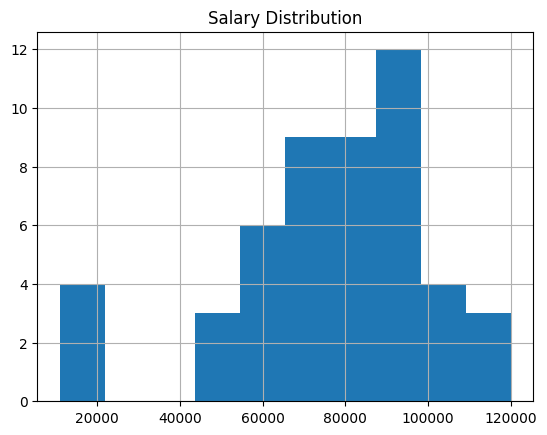

In [ ]:
df_csv["Salary"].hist() # hist(): Create a histogram of the Salary column
plt.title("Salary Distribution") # Set the title of the plot
plt.show() # show(): Display the plot

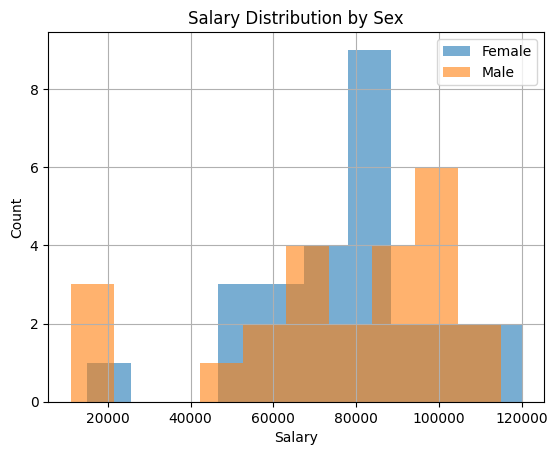

In [139]:
df_csv[df_csv["Sex"] == "Female"]["Salary"].hist(alpha=0.6, bins=10, label="Female")
df_csv[df_csv["Sex"] == "Male"]["Salary"].hist(alpha=0.6, bins=10, label="Male")
plt.legend()
plt.title("Salary Distribution by Sex")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

## Bar plots

Bar plots are great for revealing relationships between categorical (city) and numeric (salary) variables

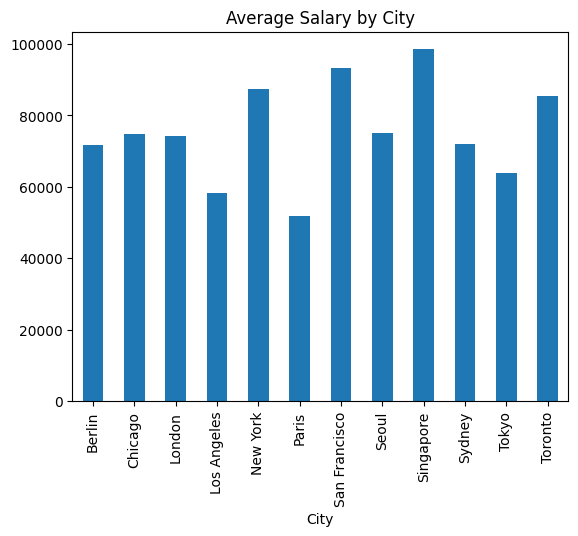

In [ ]:
avg_salary_by_city = df_csv.groupby("City")["Salary"].mean() # Group by City and calculate the mean Salary for each city
avg_salary_by_city.plot(kind="bar", title="Average Salary by City") # plot(): Create a bar plot of the average
plt.show()


## Line plots
Line plots are designed to visualize the relationship between two numeric variables, where each data values is connected to the next one. They are especially useful for visualizing the change in a number over time since each time point is naturally connected to the next time point.

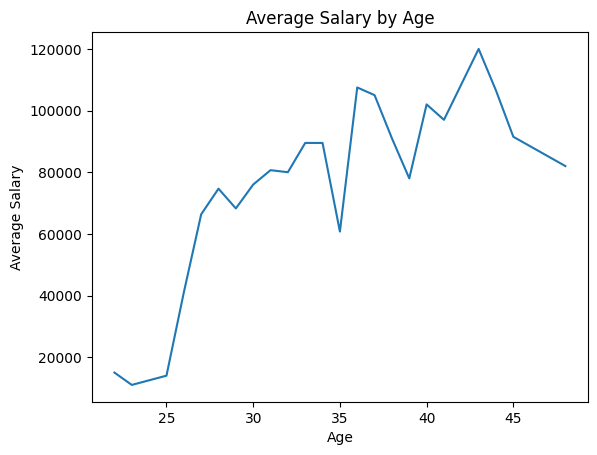

In [142]:
# Group by Age and calculate the mean Salary for each age, then plot a line chart
df_csv.groupby("Age")["Salary"].mean().plot(kind="line", title="Average Salary by Age") 
plt.xlabel("Age")
plt.ylabel("Average Salary")
plt.show() # show(): Display the plot

## Scatter plots

Great to visualize the relationships between 2 numeric variables.

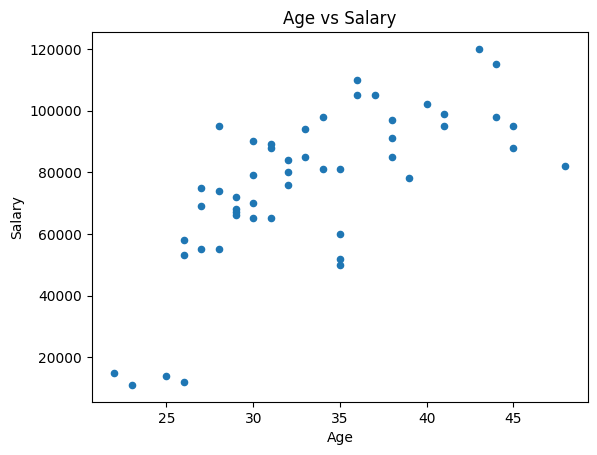

In [135]:
df_csv.plot(x="Age", y="Salary", kind="scatter")
plt.title("Age vs Salary") # Set the title of the plot
plt.show() # show(): Display the plot

In [143]:
df_csv.isna().any() # isna(): Check for missing values in the DataFrame, and any(): Check if there are any True values (i.e. any missing values) in each column

Name          False
Age           False
Sex           False
City          False
Occupation    False
Salary        False
dtype: bool